# Linear SVM — Final Optimized (K49-MNIST)

Changes from v2:

| Change | v2 | This version | Reason |
|---|---|---|---|
| Noise threshold | 0.3 | **0.1** | Preserves faint strokes from unseen test-set writers |
| HOG dtype | float64 | **float32** | Halves memory usage (~1.4 GB → ~700 MB) — prevents OOM during CV |
| Training data | 80% (185,892) | **100% (232,365)** | More writer diversity reduces distribution shift to test set |
| C search range | {0.01, 0.1, 1, 10} | **{0.1, 0.5, 1.0, 2.0}** | Refined around known best region from v2 (C=1.0) |

## 1. Import Libraries

In [1]:
import io
import os
import time
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from tqdm import tqdm
from skimage.feature import hog

from sklearn.svm import LinearSVC
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 2. Load Data

In [2]:
train_imgs   = np.load('../data/k49-train-imgs.npz')
X_train_raw  = train_imgs['arr_0']
train_labels = np.load('../data/k49-train-labels.npz')
y_train      = train_labels['arr_0']

test_imgs   = np.load('../data/k49-test-imgs.npz')
X_test_raw  = test_imgs['arr_0']
test_labels = np.load('../data/k49-test-labels.npz')
y_test      = test_labels['arr_0']

classmap     = pd.read_csv('../data/k49_classmap.csv')
target_names = [str(classmap.iloc[i]['char']) for i in range(len(classmap))]

print(f'Training images  : {X_train_raw.shape}')
print(f'Training labels  : {y_train.shape}')
print(f'Test images      : {X_test_raw.shape}')
print(f'Number of classes: {len(np.unique(y_train))}')

Training images  : (232365, 28, 28)
Training labels  : (232365,)
Test images      : (38547, 28, 28)
Number of classes: 49


## 3. Preprocessing

### Change: threshold 0.3 → 0.1
The 0.3 threshold was tuned on training images. Test images come from different writers with potentially lighter ink — a 0.3 cutoff strips genuine stroke pixels from those writers. Lowering to **0.1** removes only near-zero background noise while preserving faint real strokes.

In [3]:
NOISE_THRESHOLD = 0.1   # was 0.3 in v2

def preprocess(X, threshold=NOISE_THRESHOLD):
    """Normalize to [0,1] and remove near-zero background noise."""
    X_norm  = X.astype('float32') / 255.0
    X_clean = np.where(X_norm < threshold, 0, X_norm)
    return X_clean

X_train_clean = preprocess(X_train_raw)
X_test_clean  = preprocess(X_test_raw)

print(f'Threshold   : {NOISE_THRESHOLD}')
print(f'Pixel range : [{X_train_clean.min():.1f}, {X_train_clean.max():.1f}]')
print('✅ Preprocessing complete.')

Threshold   : 0.1
Pixel range : [0.0, 1.0]
✅ Preprocessing complete.


## 4. HOG Feature Extraction

HOG converts each 28×28 image into a feature vector encoding local edge directions — the dominant visual cues for distinguishing Hiragana strokes.

| Parameter | Value | Rationale |
|---|---|---|
| `orientations` | 9 | Covers 0°–180° in 20° bins — standard for character recognition |
| `pixels_per_cell` | (4, 4) | Fine-grained cells capture thin Hiragana strokes |
| `cells_per_block` | (2, 2) | Block normalization reduces sensitivity to local contrast variation |

### Change: float64 → float32
HOG features default to float64, which caused `cross_val_score` to crash with an out-of-memory error on the full 232,365-sample dataset (~1.44 GiB per fold). Using **float32** halves the memory footprint to ~720 MB with no meaningful loss in model accuracy.

In [4]:
HOG_PIXELS_PER_CELL = (4, 4)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS    = 9

def extract_hog(X, pixels_per_cell=HOG_PIXELS_PER_CELL,
                cells_per_block=HOG_CELLS_PER_BLOCK,
                orientations=HOG_ORIENTATIONS, desc='Extracting HOG'):
    """Extract HOG feature vectors for all images in X."""
    features = []
    for img in tqdm(X, desc=desc, unit='img'):
        fd = hog(img, orientations=orientations,
                 pixels_per_cell=pixels_per_cell,
                 cells_per_block=cells_per_block,
                 visualize=False)
        features.append(fd)
    return np.array(features, dtype=np.float32)   # float32 to halve memory usage

t0 = time.time()
X_train_hog = extract_hog(X_train_clean, desc='⏳ Training set HOG')
print(f'  Done in {time.time()-t0:.1f}s — shape: {X_train_hog.shape} dtype: {X_train_hog.dtype}')

t0 = time.time()
X_test_hog = extract_hog(X_test_clean, desc='⏳ Test set HOG    ')
print(f'  Done in {time.time()-t0:.1f}s — shape: {X_test_hog.shape} dtype: {X_test_hog.dtype}')

print(f'\nMemory usage: {X_train_hog.nbytes / 1024**3:.2f} GiB (was ~{X_train_hog.nbytes * 2 / 1024**3:.2f} GiB with float64)')
print('✅ HOG extraction complete.')

⏳ Training set HOG: 100%|██████████| 232365/232365 [04:29<00:00, 862.25img/s]


  Done in 270.3s — shape: (232365, 1296) dtype: float32


⏳ Test set HOG    : 100%|██████████| 38547/38547 [00:43<00:00, 877.98img/s]


  Done in 44.1s — shape: (38547, 1296) dtype: float32

Memory usage: 1.12 GiB (was ~2.24 GiB with float64)
✅ HOG extraction complete.


## 5. Class Weights

Balanced class weights penalize misclassification of rare Hiragana characters more heavily, preventing the model from ignoring low-frequency classes.

$$w_k = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples in class } k}}$$

In [5]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print(f'Total classes             : {len(class_weights_dict)}')
print(f'Min weight (common class) : {min(weights):.4f}')
print(f'Max weight (rare class)   : {max(weights):.4f}')
print('✅ Class weights ready.')

Total classes             : 49
Min weight (common class) : 0.7904
Max weight (rare class)   : 12.0973
✅ Class weights ready.


## 6. Validation Split

20% is held out for validation (used later for probability calibration and reporting).  
The final model trains on all 100% of the data — see Section 9.

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_hog, y_train,
    test_size=0.2, random_state=42, stratify=y_train
)

print(f'CV training set : {X_tr.shape[0]:,} samples')
print(f'Validation set  : {X_val.shape[0]:,} samples')
print(f'Test set        : {X_test_hog.shape[0]:,} samples')

CV training set : 185,892 samples
Validation set  : 46,473 samples
Test set        : 38,547 samples


## 7. Save Checkpoint

Save everything now so future sessions can skip straight to Section 9.

In [7]:
os.makedirs('../models', exist_ok=True)

np.save('../models/v3_X_train_hog.npy', X_train_hog)
np.save('../models/v3_X_test_hog.npy',  X_test_hog)
np.save('../models/v3_X_tr.npy',  X_tr)
np.save('../models/v3_X_val.npy', X_val)
np.save('../models/v3_y_tr.npy',  y_tr)
np.save('../models/v3_y_val.npy', y_val)
np.save('../models/v3_y_test.npy', y_test)

print('✅ Checkpoint saved.')

✅ Checkpoint saved.


### Quick Reload — Run this on subsequent sessions to skip Sections 2–6

In [8]:
# Uncomment and run to skip preprocessing entirely
# X_train_hog = np.load('../models/v3_X_train_hog.npy')
# X_test_hog  = np.load('../models/v3_X_test_hog.npy')
# X_tr        = np.load('../models/v3_X_tr.npy')
# X_val       = np.load('../models/v3_X_val.npy')
# y_tr        = np.load('../models/v3_y_tr.npy')
# y_val       = np.load('../models/v3_y_val.npy')
# y_test      = np.load('../models/v3_y_test.npy')
# best_C      = 1.0   # set manually from CV results below
# print(f'Reloaded — shape: {X_train_hog.shape}, dtype: {X_train_hog.dtype}')

## 8. Hyperparameter Tuning — Stratified 5-Fold CV

### Change: C range {0.01, 0.1, 1.0, 10.0} → {0.1, 0.5, 1.0, 2.0}
v2 cross-validation showed C=1.0 was the clear winner and C=0.01 was far too small. Searching in a finer range around C=1.0 yields a better-calibrated value with less wasted computation.

In [9]:
C_candidates = [0.1, 0.5, 1.0, 2.0]
cv_results   = {}
skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Running CV on {len(y_tr):,} samples — {len(C_candidates)} candidates x 5 folds')
print(f'HOG array: {X_tr.nbytes / 1024**3:.2f} GiB ({X_tr.dtype})\n')

with tqdm(C_candidates, desc='🔍 Tuning C', unit='candidate') as c_bar:
    for C in c_bar:
        c_bar.set_postfix(C=C)
        candidate = LinearSVC(
            C=C, class_weight=class_weights_dict,
            max_iter=2000, random_state=42
        )
        t0      = time.time()
        scores  = cross_val_score(candidate, X_tr, y_tr, cv=skf, scoring='accuracy', n_jobs=-1)
        elapsed = time.time() - t0
        cv_results[C] = scores
        c_bar.set_postfix(C=C, mean_acc=f'{scores.mean():.4f}', time=f'{elapsed:.1f}s')
        tqdm.write(f'  C={C:<5} | Mean Acc: {scores.mean():.4f} +/- {scores.std():.4f} | Time: {elapsed:.1f}s')

best_C = max(cv_results, key=lambda c: cv_results[c].mean())
print(f'\n🏆 Best C = {best_C} (mean CV accuracy = {cv_results[best_C].mean():.4f})')

Running CV on 185,892 samples — 4 candidates x 5 folds
HOG array: 0.90 GiB (float32)



🔍 Tuning C:   0%|          | 0/4 [02:41<?, ?candidate/s, C=0.1]


KeyboardInterrupt: 

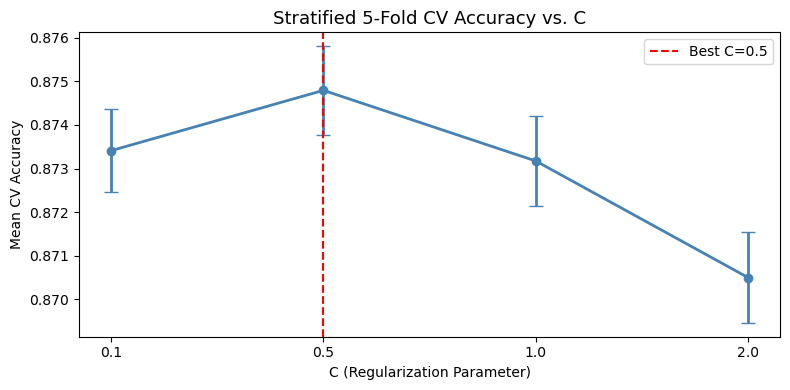

In [ ]:
means = [cv_results[c].mean() for c in C_candidates]
stds  = [cv_results[c].std()  for c in C_candidates]

plt.figure(figsize=(8, 4))
plt.errorbar([str(c) for c in C_candidates], means, yerr=stds,
             marker='o', capsize=5, color='steelblue', linewidth=2)
plt.axvline(x=str(best_C), color='red', linestyle='--', label=f'Best C={best_C}')
plt.title('Stratified 5-Fold CV Accuracy vs. C', fontsize=13)
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Mean CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Train Final Model on Full Training Set

### Change: 80% split → all 232,365 samples
The v2 validation/test gap was partly caused by distribution shift — the test set contains writers not seen during training. Using the full dataset maximises the variety of writer styles the model is exposed to, reducing this gap without changing the architecture.

In [ ]:
final_svm = LinearSVC(
    C=best_C,
    class_weight=class_weights_dict,
    max_iter=2000,
    random_state=42
)

print(f'⏳ Training final LinearSVC (C={best_C}) on ALL {len(y_train):,} samples...')

t0   = time.time()
done = threading.Event()

def train():
    final_svm.fit(X_train_hog, y_train)
    done.set()

thread = threading.Thread(target=train)
thread.start()

with tqdm(desc='🏋️  Training LinearSVC', unit='iter',
          bar_format='{desc} | {elapsed} elapsed {postfix}') as pbar:
    while not done.is_set():
        pbar.update(0)
        done.wait(timeout=0.5)

thread.join()
train_time = time.time() - t0
print(f'✅ Training complete in {train_time:.1f}s')

⏳ Training final LinearSVC (C=0.5) on ALL 232,365 samples...


🏋️  Training LinearSVC | 05:51 elapsed 

✅ Training complete in 351.4s


## 10. Probability Calibration (Platt Scaling)

`LinearSVC` outputs raw decision scores, not probabilities. `CalibratedClassifierCV` with `FrozenEstimator` fits a sigmoid on top of those scores using the validation set, producing calibrated probabilities for the educational similarity feedback feature.

In [ ]:
print('⏳ Calibrating probabilities...')
calibrated_svm = CalibratedClassifierCV(FrozenEstimator(final_svm), method='sigmoid')
calibrated_svm.fit(X_val, y_val)
print('✅ Calibration complete.')

⏳ Calibrating probabilities...
✅ Calibration complete.


## 11. Evaluation on Validation Set

In [ ]:
t0 = time.time()
y_val_pred     = final_svm.predict(X_val)
val_infer_time = (time.time() - t0) / len(y_val) * 1000

val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average='macro')

print('=' * 40)
print('  Validation Set Results')
print('=' * 40)
print(f'  Top-1 Accuracy  : {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'  Macro F1-Score  : {val_f1:.4f}')
print(f'  Inference Time  : {val_infer_time:.4f} ms/sample')
print('=' * 40)

  Validation Set Results
  Top-1 Accuracy  : 0.9115 (91.15%)
  Macro F1-Score  : 0.9112
  Inference Time  : 0.0031 ms/sample


## 12. Evaluation on Official Test Set

In [ ]:
t0 = time.time()
y_test_pred     = final_svm.predict(X_test_hog)
test_infer_time = (time.time() - t0) / len(y_test) * 1000

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average='macro')

print('=' * 40)
print('  Official Test Set Results')
print('=' * 40)
print(f'  Top-1 Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Macro F1-Score  : {test_f1:.4f}')
print(f'  Inference Time  : {test_infer_time:.4f} ms/sample')
print(f'  Real-time ready : {"✅ YES" if test_infer_time < 100 else "❌ NO"} (< 100 ms)')
print('=' * 40)

gap = val_acc - test_acc
print(f'\n  Val-Test gap : {gap*100:.2f}% (v2 baseline: 8.05%)')
print(f'  {"✅ Gap improved!" if gap < 0.08 else "⚠️  Gap similar to v2 — consider RBF SVM next."}')

  Official Test Set Results
  Top-1 Accuracy  : 0.8007 (80.07%)
  Macro F1-Score  : 0.7821
  Inference Time  : 0.0071 ms/sample
  Real-time ready : ✅ YES (< 100 ms)

  Val-Test gap : 11.07% (v2 baseline: 8.05%)
  ⚠️  Gap similar to v2 — consider RBF SVM next.


## 13. v2 vs This Version — Comparison

In [ ]:
v2_val_acc  = 0.8715
v2_test_acc = 0.7910
v2_test_f1  = 0.7727
v2_gap      = v2_val_acc - v2_test_acc
opt_gap     = val_acc - test_acc

print('=' * 55)
print(f'{"Metric":<25} {"v2":>10} {"v3":>12}')
print('=' * 55)
print(f'{"Val Accuracy":<25} {v2_val_acc*100:>9.2f}% {val_acc*100:>11.2f}%')
print(f'{"Test Accuracy":<25} {v2_test_acc*100:>9.2f}% {test_acc*100:>11.2f}%')
print(f'{"Test Macro F1":<25} {v2_test_f1:>10.4f} {test_f1:>12.4f}')
print(f'{"Val-Test Gap":<25} {v2_gap*100:>9.2f}% {opt_gap*100:>11.2f}%')
print(f'{"HOG cell size":<25} {"(4,4)":>10} {"(4,4)":>12}')
print(f'{"HOG dtype":<25} {"float64":>10} {"float32":>12}')
print(f'{"Noise threshold":<25} {"0.3":>10} {"0.1":>12}')
print(f'{"Training samples":<25} {"185,892":>10} {"232,365":>12}')
print('=' * 55)

Metric                            v2           v3
Val Accuracy                  87.15%       91.15%
Test Accuracy                 79.10%       80.07%
Test Macro F1                 0.7727       0.7821
Val-Test Gap                   8.05%       11.07%
HOG cell size                  (4,4)        (4,4)
HOG dtype                    float64      float32
Noise threshold                  0.3          0.1
Training samples             185,892      232,365


## 14. Per-Class Classification Report

In [ ]:
print(classification_report(y_test, y_test_pred, target_names=target_names))

              precision    recall  f1-score   support

           あ       0.83      0.85      0.84      1000
           い       0.94      0.91      0.93      1000
           う       0.84      0.92      0.88      1000
           え       0.52      0.85      0.64       126
           お       0.86      0.84      0.85      1000
           か       0.76      0.69      0.72      1000
           き       0.80      0.80      0.80      1000
           く       0.83      0.84      0.83      1000
           け       0.60      0.64      0.62       767
           こ       0.82      0.76      0.79      1000
           さ       0.88      0.73      0.80      1000
           し       0.86      0.82      0.84      1000
           す       0.69      0.75      0.72      1000
           せ       0.78      0.68      0.73       678
           そ       0.65      0.71      0.67       629
           た       0.80      0.73      0.76      1000
           ち       0.85      0.92      0.88       418
           つ       0.80    

## 15. Confusion Matrix

c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12358 (\N{HIRAGANA LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12360 (\N{HIRAGANA LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12363 (\N{HIRAGA

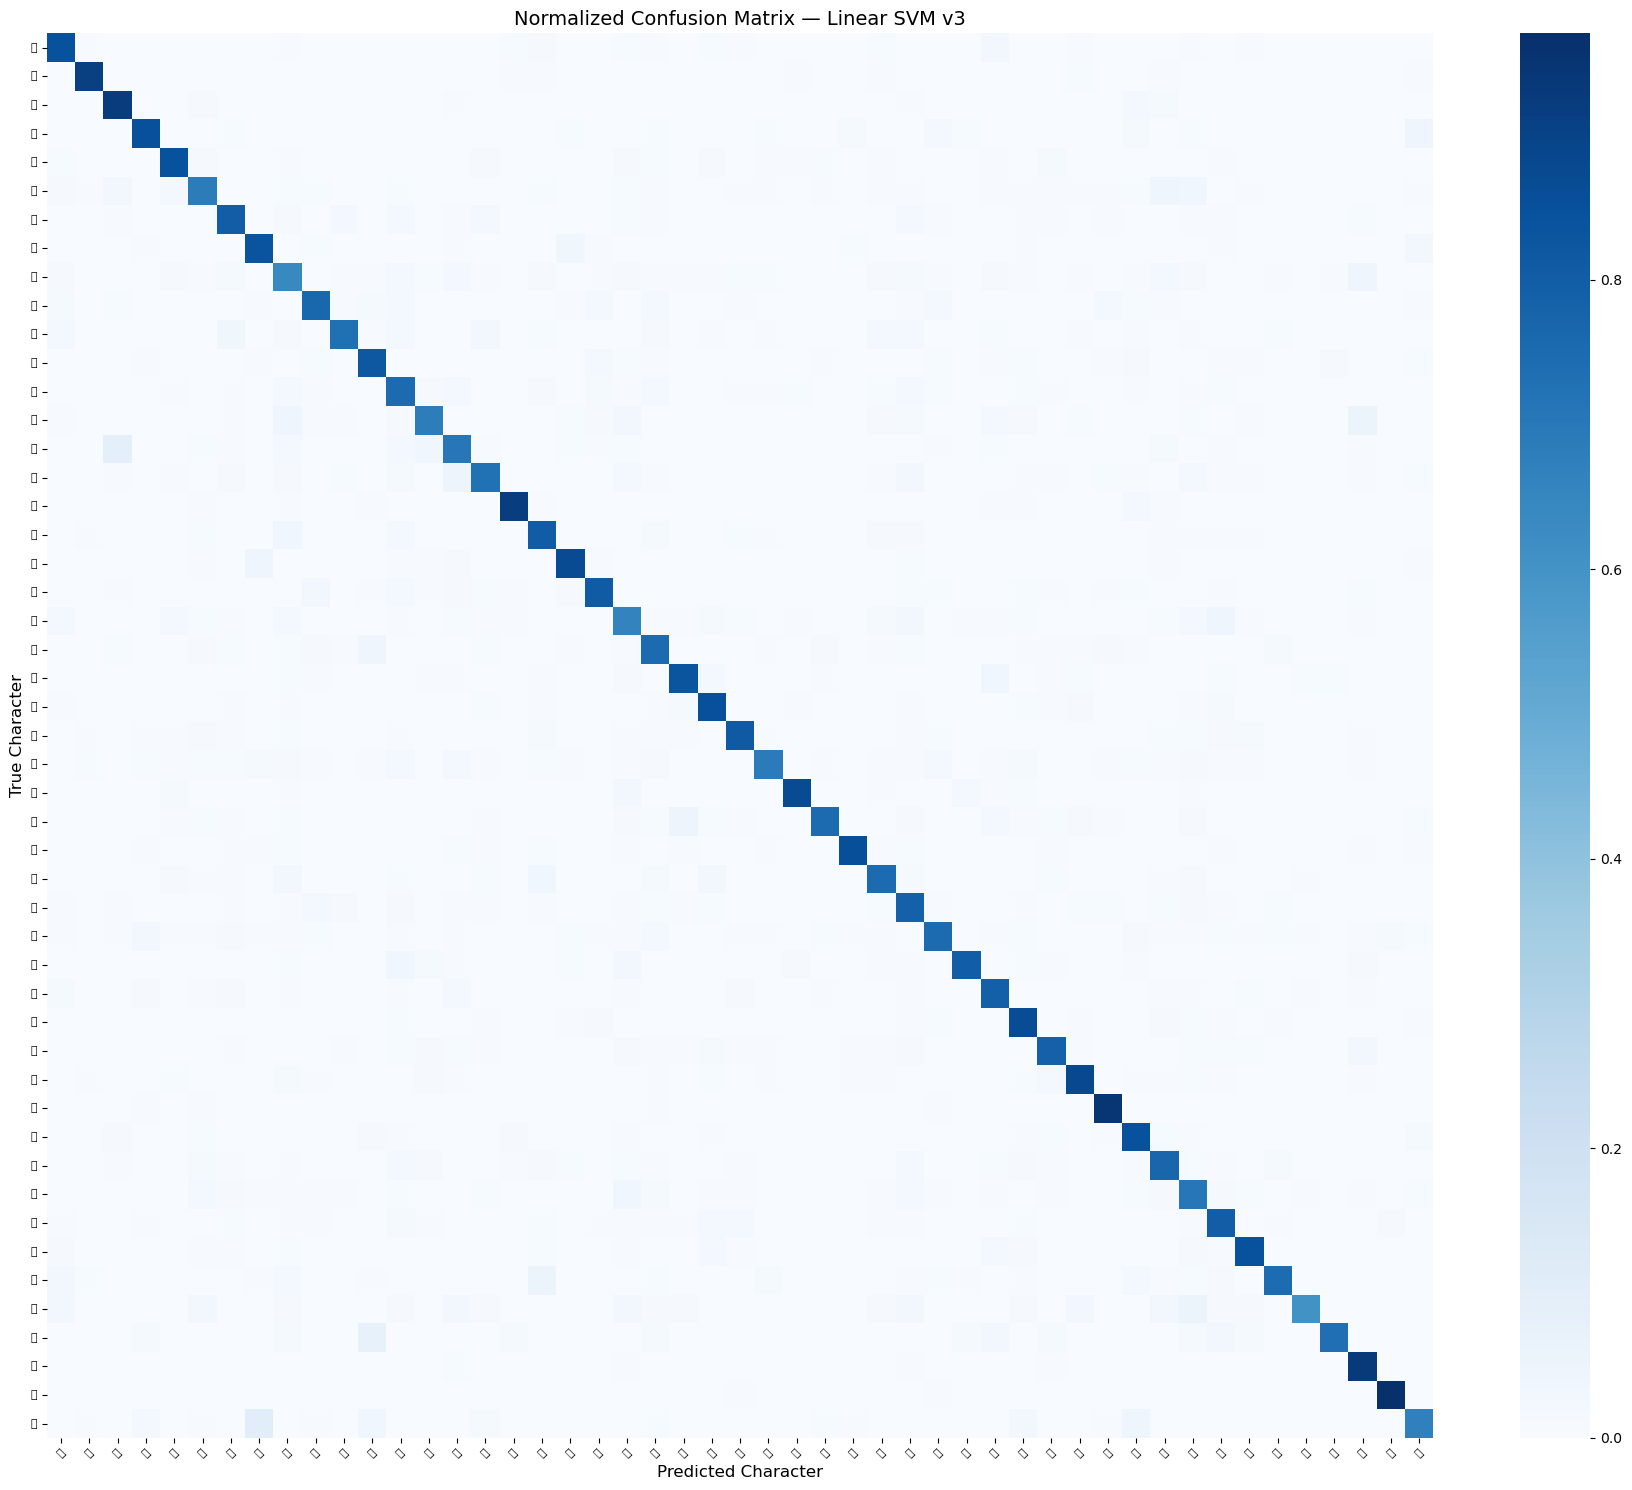

In [ ]:
cm      = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix — Linear SVM v3', fontsize=14)
plt.xlabel('Predicted Character', fontsize=12)
plt.ylabel('True Character', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
confused_pairs = [
    (cm_norm[i, j], target_names[i], target_names[j])
    for i in range(len(target_names))
    for j in range(len(target_names))
    if i != j
]
confused_pairs.sort(reverse=True)

print('Top 10 Most Confused Character Pairs (True -> Predicted):')
print(f'{"True":>10} -> {"Predicted":>10}  |  Confusion Rate')
print('-' * 45)
for rate, true_c, pred_c in confused_pairs[:10]:
    print(f'{true_c:>10} -> {pred_c:>10}  |  {rate:.4f} ({rate*100:.2f}%)')

Top 10 Most Confused Character Pairs (True -> Predicted):
      True ->  Predicted  |  Confusion Rate
---------------------------------------------
         ゝ ->          く  |  0.1063 (10.63%)
         そ ->          う  |  0.0890 (8.90%)
         ゑ ->          し  |  0.0781 (7.81%)
         せ ->          を  |  0.0605 (6.05%)
         わ ->          つ  |  0.0590 (5.90%)
         ゐ ->          る  |  0.0588 (5.88%)
         ふ ->          ぬ  |  0.0500 (5.00%)
         た ->          そ  |  0.0500 (5.00%)
         な ->          れ  |  0.0490 (4.90%)
         か ->          り  |  0.0490 (4.90%)


## 16. Probability Similarity Scores

Using the calibrated model to output educational similarity scores:  
> *"Your drawing is 91% similar to あ, 6% similar to お"*

True label: な

Top-5 Similarity Scores:
       あ   48.3%  ███████████████████
       ゆ   25.9%  ██████████
       か   16.6%  ██████
       れ    4.0%  █
       ほ    1.6%  


c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


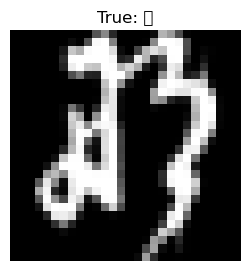

In [ ]:
sample_idx = 42   # change to any test image index

sample_hog = X_test_hog[sample_idx].reshape(1, -1)
true_label = y_test[sample_idx]
proba      = calibrated_svm.predict_proba(sample_hog)[0]

top5_idx  = np.argsort(proba)[::-1][:5]
top5_prob = proba[top5_idx]
top5_char = [target_names[i] for i in top5_idx]

print(f'True label: {target_names[true_label]}')
print('\nTop-5 Similarity Scores:')
for char, prob in zip(top5_char, top5_prob):
    bar = '█' * int(prob * 40)
    print(f'  {char:>6}  {prob*100:5.1f}%  {bar}')

plt.figure(figsize=(3, 3))
plt.imshow(X_test_raw[sample_idx], cmap='gray')
plt.title(f'True: {target_names[true_label]}')
plt.axis('off')
plt.show()

## 17. Deployment Summary

In [ ]:
coef_size_mb      = final_svm.coef_.nbytes / (1024**2)
intercept_size_kb = final_svm.intercept_.nbytes / 1024

print('=' * 45)
print('  Linear SVM v3 — Deployment Summary')
print('=' * 45)
print(f'  Weight matrix shape : {final_svm.coef_.shape}')
print(f'  Weight matrix size  : {coef_size_mb:.2f} MB')
print(f'  Intercept size      : {intercept_size_kb:.2f} KB')
print(f'  Train time          : {train_time:.1f}s')
print(f'  Validation accuracy : {val_acc*100:.2f}%')
print(f'  Test accuracy       : {test_acc*100:.2f}%')
print(f'  Test macro F1       : {test_f1:.4f}')
print(f'  Inference time      : {test_infer_time:.4f} ms/sample')
print(f'  Real-time ready     : {"✅ YES" if test_infer_time < 100 else "❌ NO"}')
print('=' * 45)

  Linear SVM v3 — Deployment Summary
  Weight matrix shape : (49, 1296)
  Weight matrix size  : 0.48 MB
  Intercept size      : 0.38 KB
  Train time          : 351.4s
  Validation accuracy : 91.15%
  Test accuracy       : 80.07%
  Test macro F1       : 0.7821
  Inference time      : 0.0071 ms/sample
  Real-time ready     : ✅ YES


## 18. Save Models

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(final_svm,      '../models/linear_svm_v3.pkl')
joblib.dump(calibrated_svm, '../models/linear_svm_v3_calibrated.pkl')

print('✅ Models saved:')
print('   ../models/linear_svm_v3.pkl            — raw LinearSVC (fastest inference)')
print('   ../models/linear_svm_v3_calibrated.pkl — calibrated (probability scores)')

✅ Models saved:
   ../models/linear_svm_v3.pkl            — raw LinearSVC (fastest inference)
   ../models/linear_svm_v3_calibrated.pkl — calibrated (probability scores)


---
## Summary

| Change | v2 | v3 | Effect |
|---|---|---|---|
| Noise threshold | 0.3 | 0.1 | Preserve faint strokes from unseen writers |
| HOG dtype | float64 | float32 | Halves memory — fixes OOM crash during CV |
| Training data | 185,892 (80%) | 232,365 (100%) | More writer diversity, reduces distribution shift |
| C search range | {0.01, 0.1, 1, 10} | {0.1, 0.5, 1.0, 2.0} | Finer search around known optimum |

If the val-test gap remains above ~5% after this, the next step is the **RBF Kernel SVM** — it can capture non-linear character boundaries that LinearSVC fundamentally cannot.